In [7]:
import pandas as pd
import re

In [20]:
df = pd.read_csv('data/tickets/tickets-per-day-per-code.csv')

In [21]:
df.head()

,Issue Date,Violation Code,Tickets Issued
0,06/04/2025,6,30
1,10/12/2023,22,25
2,03/12/2024,22,20
3,06/30/2026,40,2
4,09/13/2024,99,22


In [22]:
def standardize_column_names(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase, strip, replace spaces with underscores, remove non-alphanumerics/underscores."""
    def clean_name(c):
        c = c.strip().lower()
        c = c.replace(" ", "_")
        c = re.sub(r"[^0-9a-zA-Z_]", "", c)
        c = re.sub(r"_+", "_", c)
        return c
    df = df.copy()
    df.columns = [clean_name(c) for c in df.columns]
    return df


df = standardize_column_names(df)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57636 entries, 0 to 57635
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   issue_date      57636 non-null  object
 1   violation_code  57636 non-null  int64 
 2   tickets_issued  57636 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 1.3+ MB


In [24]:
df['dt_issue_date'] = pd.to_datetime(df['issue_date'])
df.head()

,issue_date,violation_code,tickets_issued,dt_issue_date
0,06/04/2025,6,30,2025-06-04
1,10/12/2023,22,25,2023-10-12
2,03/12/2024,22,20,2024-03-12
3,06/30/2026,40,2,2026-06-30
4,09/13/2024,99,22,2024-09-13


In [25]:
! pip install openpyxl
data_dict = pd.read_excel('data/tickets/ParkingViolationCodes_January2020.xlsx')


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python3 -m pip install --upgrade pip


In [26]:
data_dict = standardize_column_names(data_dict)
data_dict

,violation_code,violation_description,manhattan_96th_st_belowfine_amount_,all_other_areasfine_amount_
0,1,FAILURE TO DISPLAY BUS PERMIT,515,515
1,2,NO OPERATOR NAM/ADD/PH DISPLAY,515,515
2,3,UNAUTHORIZED PASSENGER PICK-UP,515,515
3,4,BUS PARKING IN LOWER MANHATTAN,115,115
4,5,BUS LANE VIOLATION,50,50
...,...,...,...,...
92,93,REMOVE/REPLACE FLAT TIRE,65,65
93,96,RAILROAD CROSSING,95,95
94,97,VACANT LOT,65,45
95,98,OBSTRUCTING DRIVEWAY,95,95


In [27]:
print(df.shape)

(57636, 4)


In [30]:
df_joined = pd.merge(left=df, right=data_dict, on='violation_code')
df_joined.head()

,issue_date,violation_code,tickets_issued,dt_issue_date,violation_description,manhattan_96th_st_belowfine_amount_,all_other_areasfine_amount_
0,06/04/2025,6,30,2025-06-04,OVERNIGHT TRACTOR TRAILER PKG,265,265
1,10/12/2023,22,25,2023-10-12,NO STAND TAXI/FHV RELIEF STAND,115,115
2,03/12/2024,22,20,2024-03-12,NO STAND TAXI/FHV RELIEF STAND,115,115
3,06/30/2026,40,2,2026-06-30,FIRE HYDRANT,115,115
4,09/13/2024,99,22,2024-09-13,OTHER,105,105


In [31]:
cols_to_keep = ['dt_issue_date', 'violation_description', 'tickets_issued']

df_joined = df_joined[cols_to_keep].copy()



In [33]:
df_joined.to_csv('data/tickets/processed_tickets_per_day_with_description.csv', index=False)

# End Pipeline Process

---

# Being EDA Process

In [8]:
import pandas as pd 
df = pd.read_csv('data/tickets/processed_tickets_per_day_with_description.csv')

In [9]:
df.head()

,dt_issue_date,violation_description,tickets_issued
0,2025-06-04,OVERNIGHT TRACTOR TRAILER PKG,30
1,2023-10-12,NO STAND TAXI/FHV RELIEF STAND,25
2,2024-03-12,NO STAND TAXI/FHV RELIEF STAND,20
3,2026-06-30,FIRE HYDRANT,2
4,2024-09-13,OTHER,22


In [10]:
print(df.isnull().sum())

dt_issue_date            0
violation_description    0
tickets_issued           0
dtype: int64


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
### inspect time ranges

In [13]:
tix_per_day = df.groupby('dt_issue_date')['tickets_issued'].sum()
tix_per_day

dt_issue_date
1972-06-19    1
1972-11-03    1
2000-01-02    2
2000-01-04    1
2000-01-05    1
             ..
2055-03-12    1
2055-03-22    1
2055-04-12    1
2055-05-02    1
2055-05-12    1
Name: tickets_issued, Length: 2174, dtype: int64

<Axes: xlabel='dt_issue_date'>

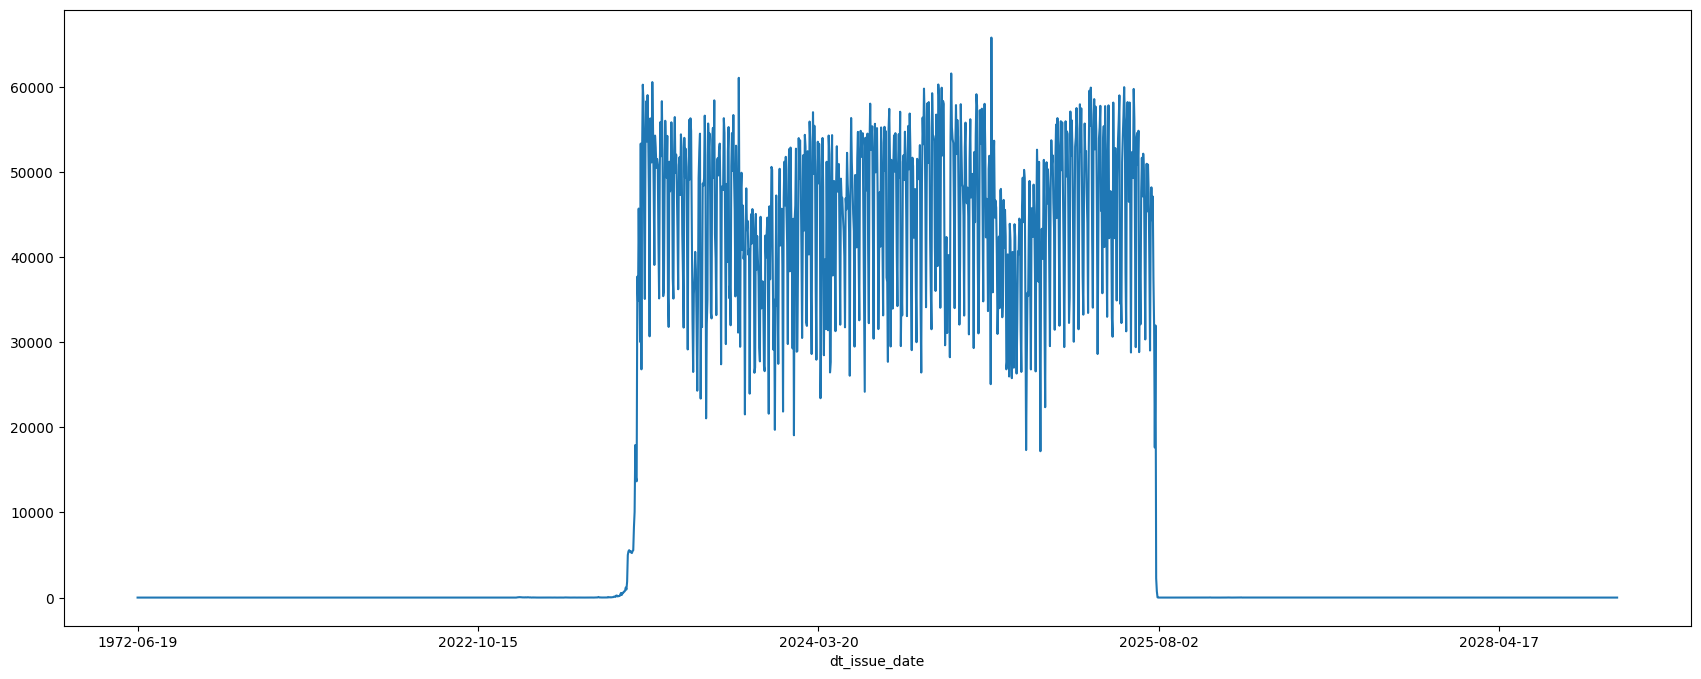

In [19]:
tix_per_day.plot(figsize=(21,8))

In [22]:
vc = df.dt_issue_date.value_counts()
vc.sort_index() 

dt_issue_date
1972-06-19    1
1972-11-03    1
2000-01-02    2
2000-01-04    1
2000-01-05    1
             ..
2055-03-12    1
2055-03-22    1
2055-04-12    1
2055-05-02    1
2055-05-12    1
Name: count, Length: 2174, dtype: int64

### Removing the dates that are before or after we know our data is good.

In [26]:
vcdf = vc.reset_index()
vcdf[vcdf['count'] > 2].shape

(1157, 2)

In [15]:
# import seaborn as sns
# sns.set_theme('paper')
# sns.lineplot(data=tix_per_day)

In [16]:
# ! pip install ydata-profiling

In [18]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, explorative=True)
profile.to_file("report.html")

# ! python3 -m http.server 8000

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 478.86it/s]


Serving HTTP on 0.0.0.0 port 8000 (http://0.0.0.0:8000/) ...
127.0.0.1 - - [07/Sep/2025 21:03:34] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [07/Sep/2025 21:03:34] code 404, message File not found
127.0.0.1 - - [07/Sep/2025 21:03:34] "GET /favicon.ico HTTP/1.1" 404 -
127.0.0.1 - - [07/Sep/2025 21:03:35] "GET /report.html HTTP/1.1" 200 -

Keyboard interrupt received, exiting.
^C
